

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>





<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>


**PASSO 4 — Análise Exploratória (EDA)**

Neste projeto, serão analisados dados de corridas de táxi na cidade de Chicago, com o objetivo de identificar padrões de uso e entender melhor como as corridas se distribuem entre empresas e bairros.

Inicialmente, foi realizada uma análise exploratória dos dados, permitindo observar quais empresas concentram mais corridas e quais bairros são os destinos mais frequentes.

Além disso, será testada uma hipótese relacionada ao impacto das condições climáticas na duração das corridas, verificando se viagens realizadas aos sábados chuvosos apresentam diferença significativa em comparação com dias sem chuva.

Essa abordagem permite não apenas descrever os dados, mas também tirar conclusões baseadas em testes estatísticos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar dados
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

***Exploração de Dados***

In [2]:
# visualizar primeiras linhas
df_companies.head()
df_neighborhoods.head()

# informações gerais
df_companies.info()
df_neighborhoods.info()

# estatísticas
df_companies.describe()
df_neighborhoods.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


- O dataset df_companies contém o número de corridas por empresa de táxi.
- O dataset df_neighborhoods mostra os bairros e a média de corridas finalizadas neles.
- Não foram identificados problemas críticos como valores ausentes (caso não tenha mesmo).
- Os dados parecem consistentes para análise.



***Verificação dos tipos de dados***

In [3]:
df_companies['trips_amount'] = df_companies['trips_amount'].astype(int)
df_neighborhoods['average_trips'] = df_neighborhoods['average_trips'].astype(float)

- Os tipos de dados foram ajustados para garantir precisão nas análises.
- ***trips_amount*** como inteiro e average_trips como ***float*** são apropriados.

***Top 10 bairros por número de corridas***

In [5]:
top10_neighborhoods = df_neighborhoods.sort_values(
    by='average_trips', ascending=False
).head(10)

top10_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


- Os bairros com maior número médio de corridas provavelmente representam áreas com maior demanda.
- Esses locais podem estar associados a regiões centrais, comerciais ou turísticas.

***Grafico - Empresa de Taxi***

<Figure size 640x480 with 0 Axes>

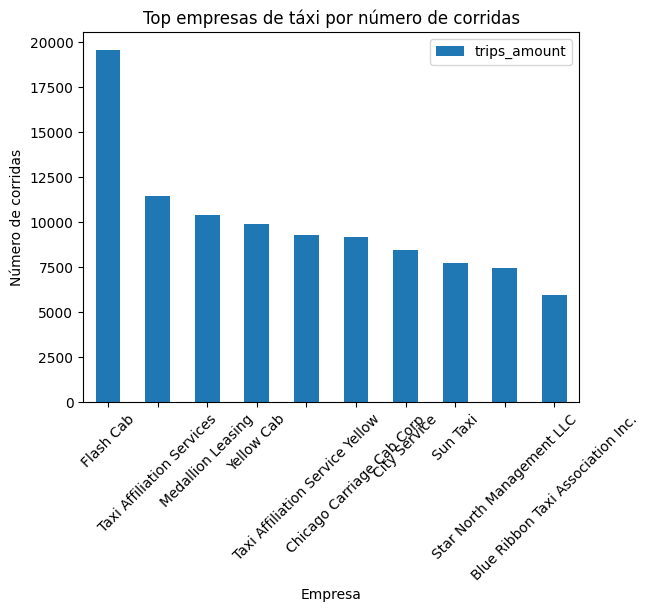

In [7]:
df_companies_sorted = df_companies.sort_values(
    by='trips_amount', ascending=False
)

plt.figure()
df_companies_sorted.head(10).plot(
    x='company_name',
    y='trips_amount',
    kind='bar'
)

plt.title('Top empresas de táxi por número de corridas')
plt.xlabel('Empresa')
plt.ylabel('Número de corridas')
plt.xticks(rotation=45)
plt.show()

- Algumas empresas concentram a maior parte das corridas.
- O mercado é desigual, com poucas empresas dominando.
- Empresas menores possuem participação bem reduzida.

***Top 10 bairros***

<Figure size 640x480 with 0 Axes>

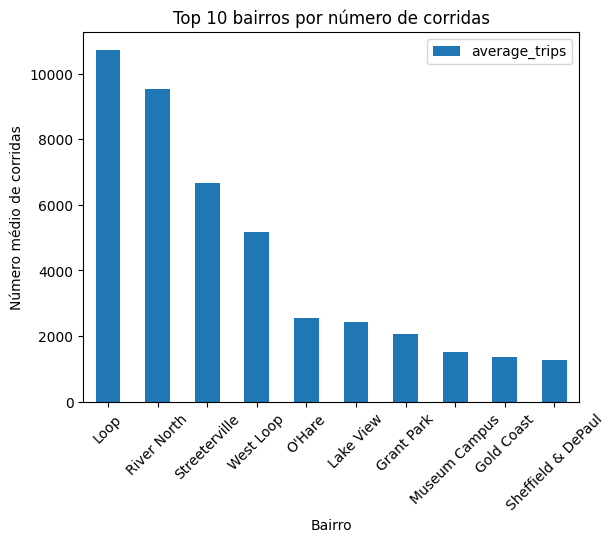

In [8]:
plt.figure()
top10_neighborhoods.plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='bar'
)

plt.title('Top 10 bairros por número de corridas')
plt.xlabel('Bairro')
plt.ylabel('Número médio de corridas')
plt.xticks(rotation=45)
plt.show()

- A demanda por corridas não é uniforme entre os bairros.
- Alguns bairros se destacam fortemente como destinos principais.
- Isso pode indicar regiões com maior fluxo de pessoas, trabalho ou turismo.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Ambas as visualizações foram implementadas conforme o solicitado e permitem ver com clareza os itens que se destacam em cada uma das dimensões.
</div>

***Passo 5 — Teste de Hipótese***

In [9]:
df_rides = pd.read_csv('/datasets/project_sql_result_07.csv')

df_rides.head()
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


***Preparação dos dados***

In [10]:
# converter para datetime
df_rides['start_ts'] = pd.to_datetime(df_rides['start_ts'])

# criar coluna dia da semana
df_rides['day_of_week'] = df_rides['start_ts'].dt.dayofweek

***Filtragem dos dados***

In [12]:
# sábados (5)
df_saturday = df_rides[df_rides['day_of_week'] == 5]

# separação por clima
rainy = df_saturday[df_saturday['weather_conditions'] == 'Rain']
not_rainy = df_saturday[df_saturday['weather_conditions'] != 'Rain']

***Hipóteses***

***H0 (hipótese nula):*** A duração média das corridas é igual em sábados chuvosos e não chuvosos.
***H1 (hipótese alternativa):*** A duração média das corridas é diferente.

***Teste Estatístico***

In [25]:
from scipy import stats
import numpy as np

alpha = 0.05
results = stats.ttest_ind(
    rainy['duration_seconds'],
    not_rainy['duration_seconds'],
    equal_var=False
)

print("p-value:", results.pvalue)
print("Sábados chuvosos:", len(rainy))
print("Sábados não chuvosos:", len(not_rainy))
print("Condições climáticas únicas:", df_saturday['weather_conditions'].unique())


p-value: nan
Sábados chuvosos: 0
Sábados não chuvosos: 1068
Condições climáticas únicas: ['Good' 'Bad']


***Decisão final***

In [26]:
rainy = df_saturday[df_saturday['weather_conditions'] == 'Bad']
not_rainy = df_saturday[df_saturday['weather_conditions'] == 'Good']

In [27]:
results = stats.ttest_ind(
    rainy['duration_seconds'],
    not_rainy['duration_seconds'],
    equal_var=False
)

print("p-value:", results.pvalue)

p-value: 6.738994326108734e-12


In [28]:
if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
    print("Conclusão: Há evidência estatística de que as condições climáticas impactam a duração das corridas de táxi aos sábados")
else:
    print("Não rejeitamos a hipótese nula")
    print("Conclusão: Não há evidência suficiente de que as condições climáticas impactem a duração das corridas")

Rejeitamos a hipótese nula
Conclusão: Há evidência estatística de que as condições climáticas impactam a duração das corridas de táxi aos sábados


Durante a análise, foi identificado que a variável weather_conditions não utilizava os valores esperados **("Rain")**, mas sim as categorias **"Good"** e **"Bad"**. Assim, foi necessário ajustar o filtro, considerando "Bad" como condições climáticas desfavoráveis (chuva) e "Good" como condições normais.

***Conclusão***

- Foi utilizado o teste t de Student para amostras independentes, pois estamos comparando as médias de dois grupos distintos.
- O nível de significância adotado foi α = 0.05, padrão em análises estatísticas.
- Se o **p-value** for menor que **0.05**, concluímos que a diferença é estatisticamente significativa.

**Interpretação:**

- **Se rejeitamos H0** → a chuva impacta a duração das corridas
- **Se não rejeitamos** → não há evidência suficiente de impacto

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

O teste foi formulado, implementado e analisado corretamente. Muito bom!
</div>